# Imports

In [1]:
from ModifiedNEAT.nn.base import NeatModule
from load_data import MnistDataloader
from ModifiedNEAT.util.storage import STORAGE_DIR
from ModifiedNEAT.util.qol import manage_params
from ModifiedNEAT.util.datetime import clock, eta
from ModifiedNEAT.util.storage import save, load
from ModifiedNEAT.util.fancy_text import CM, Fore

import ModifiedNEAT as meat
import ModifiedNEAT.nn as mnn
import ModifiedNEAT.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import warnings

from torch import Tensor
from torch.optim import Optimizer
from torch.nn.utils import clip_grad_norm_
from torchvision import transforms
from numpy import ndarray as CPUArray
from typing import Union
from copy import deepcopy
from matplotlib.pyplot import Axes
from numba.core.errors import NumbaPerformanceWarning

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
GENOMES = 100

In [3]:
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

# Load Data

In [4]:
ABS_PATH = 'D:\PycharmProjects\Modified-NEAT\examples\mnist\mnist_data\\'
loader = MnistDataloader(
    f"{ABS_PATH}train-images.idx3-ubyte",
    f"{ABS_PATH}train-labels.idx1-ubyte",
    f"{ABS_PATH}t10k-images.idx3-ubyte",
    f"{ABS_PATH}t10k-labels.idx1-ubyte",
)
RESIZE = (16, 16)
(train_inp, train_out), (eval_inp, eval_out) = loader.load_data(
    GENOMES, 1000, 21000, resize=RESIZE, rand_rot=False, rand_flip=False, batch_size=128,
    normalize=True,
    device='cpu', dtype=torch.float32
)
train_inp.shape, train_out.shape, eval_inp.shape, eval_out.shape

Loaded 1000 records.
Loaded 10000 records.


(torch.Size([100, 1000, 1, 16, 16]),
 torch.Size([100, 1000]),
 torch.Size([100, 10000, 1, 16, 16]),
 torch.Size([100, 10000]))

In [5]:
def tensor_memory(tensor: Tensor):
    """

    :param tensor: PyTorch tensor
    :return: Memory in Megabytes
    """
    return tensor.numel() * tensor.element_size() / (1024 ** 2)

In [6]:
tensor_memory(eval_inp)

976.5625

In [7]:
[(torch.max(t).cpu(), torch.min(t).cpu()) for t in [train_inp, eval_inp]]

[(tensor(1.0000), tensor(0.)), (tensor(1.0000), tensor(0.))]

In [8]:
train_inp.device, train_inp.dtype, train_inp.device, train_out.dtype

(device(type='cpu'), torch.float32, device(type='cpu'), torch.int64)

In [9]:
torch.max(train_inp)

tensor(1.0000)

In [10]:
IMG_SHAPE = train_inp.shape[3:]
IMG_SHAPE

torch.Size([16, 16])

# View data

In [11]:
def show_image(image: Tensor, title: str = None, size: tuple[int, int] = None, cmap='binary', axis: Axes = None):
    if size is None:
        size = (360, 360)
    if image.ndim == 3:
        image = image.permute(1, 2, 0)
    elif image == 2:
        pass
    else:
        raise ValueError(f"Unsupported ndim")
    image = image.cpu()
    if axis is None:
        _, axis = plt.subplots(1, 1, figsize=(size[0] * 0.01, size[1] * 0.01))
    axis.imshow(image, cmap=cmap)
    if title is not None:
        axis.set_title(title)
    axis.set_axis_off()
    if axis is None:
        plt.show()

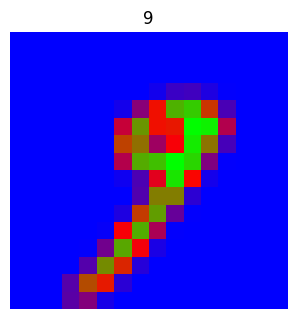

In [12]:
rand_train_idx = np.random.randint(0, len(train_inp))
show_image(train_inp[0, rand_train_idx], train_out[0, rand_train_idx].item(), cmap='brg')

In [13]:
def show_batch(images: Tensor, predictions: Tensor = None, labels: Tensor = None, columns=8,
               size: tuple[int, int] = None, cmap='binary', no_axes=True):
    if size is None:
        size = (720, 1080)
    if images.ndim == 4:
        images = images.permute(0, 2, 3, 1)
    elif images == 3:
        pass
    else:
        raise ValueError(f"Unsupported ndim")

    images = images.cpu()
    rows = math.ceil(len(images) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(size[1] * 0.01, size[0] * 0.01))
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]

    for index, (axis, image) in enumerate(zip(axes, images)):
        axis.imshow(image, cmap=cmap)
        title = ''
        if predictions is not None:
            title += f"P={predictions[index].cpu().item()}"
        if labels is not None:
            title += f"L={labels[index].cpu().item()}"
        if len(title) > 0:
            axis.set_title(title)
        if no_axes:
            axis.set_axis_off()
    plt.show()

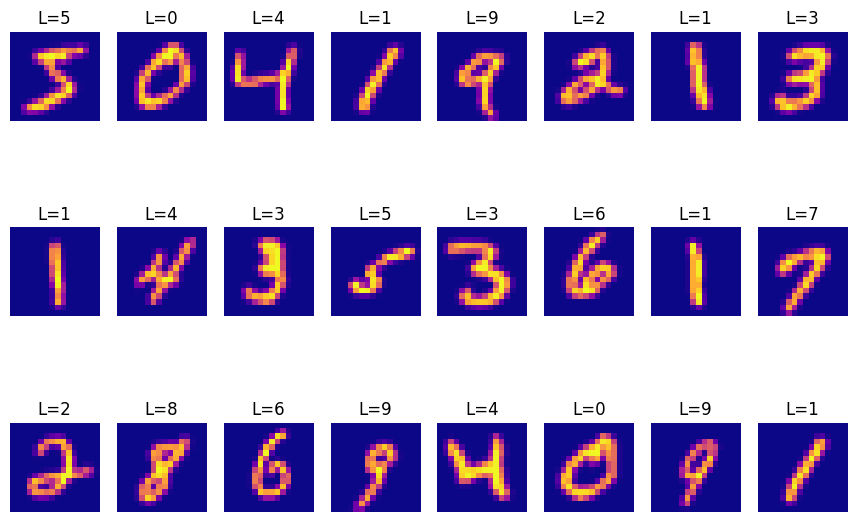

In [14]:
show_batch(train_inp[0, :24], labels=train_out[0, :24], cmap='plasma')

# Model Architecture

In [15]:
from typing import Iterable

class Average(nn.Module):
    def __init__(self, dims=None, keepdims=False):
        super(Average, self).__init__()
        self.dims = dims
        self.keepdims = keepdims

    def forward(self, input: Tensor) -> Tensor:
        return torch.mean(input, dim=self.dims, keepdim=self.keepdims)

class Permute(nn.Module):
    def __init__(self, dims: int | Iterable[int]):
        super(Permute, self).__init__()
        if not isinstance(dims, Iterable):
            dims = [dims]
        self.dims = tuple(dims)

    def forward(self, input: Tensor) -> Tensor:
        extra = tuple(range(max(0, input.ndim-len(self.dims))))
        return input.permute(extra+self.dims)

    def extra_repr(self):
        return f"dims={self.dims}"

class SimpleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, dim_size: int, layers: int, kernel_size: int, img_size: tuple[int, int],
                 fc_size: int, div=1, actv=nn.SiLU(), bias=False, device='cpu', dtype=torch.float32):
        super().__init__()
        sequence = nn.ModuleList()
        padding = 0
        for layer_idx in range(layers+1):
            # size_ = tuple([dim - (kernel_size-1) * layer_idx for dim in img_size])
            if layer_idx < layers:
                # if layer_idx == 0:
                    sequence.append(mnn.Conv2d(
                        inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                        outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                        kernel_size=kernel_size, bias=bias, device=device, dtype=dtype,
                        padding=padding, padding_mode='zeros'
                    ))
                # else:
                #    sequence.append(mnn.ResidualBlock(
                #         inputs if layer_idx == 0 else dim_size+(dim_size//div*(layer_idx-1)),
                #         outputs if layer_idx == layers else dim_size+(dim_size//div*layer_idx),
                #         kernel_size=kernel_size, bias=bias, device=device, dtype=dtype,
                #         padding=padding, padding_mode='zeros', image_ndim=2, norm_groups=1,
                #    ))
                # if layer_idx == layers-1:
                    sequence.append(
                        mnn.GroupNorm(1, dim_size+(dim_size//div*layer_idx) if layer_idx != layers else outputs,
                                      bias=bias, device=device, dtype=dtype)
                    )
                    sequence.append(actv)
            else:
                # fc_inputs = (dim_size+(dim_size//div*(layers-1))) * math.prod(img_size)
                ndim = len(img_size) + 1 # Convolution dimensions + Feature dimension
                permutation = list(range(-ndim+1, 0)) + [-ndim]
                sequence.extend([
                    Permute(permutation),
                    nn.Flatten(-(len(img_size)+1), -1),
                    nn.AdaptiveAvgPool1d(fc_size),
                    mnn.Linear(fc_size, outputs, bias=bias, device=device, dtype=dtype)
                ])
        self.sequence = mnn.Sequential(*sequence)
        # self.mean_std = mnn.Linear(fc_size, outputs * 2, bias=bias, device=device, dtype=dtype)
        # self.mean = mnn.Linear(fc_size, outputs, bias=bias, device=device, dtype=dtype)

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.dim_size   = dim_size
        self.kernel_size = kernel_size
        self.layers     = layers
        self.div        = div
        self.bias       = bias
        self.fc_size    = fc_size

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        tensor = (tensor - 0.5) * 2.0
        tensor = self.sequence(tensor, keys=keys)
        # mean, log_std = torch.chunk(self.mean_std(tensor, keys=keys), 2, -1)
        # std = torch.exp(torch.tanh(log_std) * 6)
        # dist = torch.distributions.Normal(mean, std)
        # tensor = dist.sample()
        # tensor = self.mean(tensor, keys=keys)
        # tensor = F.log_softmax(tensor, dim=-1)
        return tensor

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None):
        return torch.argmax(self.forward(tensor, keys), dim=-1)

DyParam = Union[int, list[int]]

class EnsembleCNN(meat.NeatModule):
    def __init__(self, inputs: int, outputs: int, kernel_sizes: DyParam, dim_sizes: DyParam, layers: DyParam,
                 img_size: tuple[int, int], fc_size: int, divs: DyParam, actv=nn.SiLU(),
                 bias=False, device='cpu', dtype=torch.float32):
        super(EnsembleCNN, self).__init__()
        if isinstance(kernel_sizes, (int, float)):
            kernel_sizes = [kernel_sizes]

        self.networks: list[SimpleCNN] = nn.ModuleList()
        for k_idx, kernel_size in enumerate(kernel_sizes):
            dim_size    = dim_sizes if isinstance(dim_sizes, (int, float)) else dim_sizes[min(k_idx, len(dim_sizes)-1)]
            layer_num   = layers if isinstance(layers, (int, float)) else layers[min(k_idx, len(layers)-1)]
            div         = divs if isinstance(divs, (int, float)) else divs[min(k_idx, len(divs)-1)]
            self.networks.append(SimpleCNN(
                inputs, outputs, dim_size, layer_num, kernel_size, img_size, fc_size, div, actv, bias, device, dtype
            ))

        # Attributes
        self.inputs     = inputs
        self.outputs    = outputs
        self.img_size   = img_size
        self.bias       = bias

        # States
        self.device     = device
        self.dtype      = dtype

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        summation = []
        for module in self.networks:
            summation.append(module(tensor, keys=keys))
        return torch.sum(torch.stack(summation), dim=0)

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        return torch.argmax(self.forward(tensor, keys=keys, verbose=verbose), dim=-1)

    def guess(self, tensor, keys: Union[int, list[int]] = None):
        logits = self.forward(tensor, keys=keys)
        dist = torch.distributions.Categorical(F.softmax(logits, -1))
        return dist.sample()

    def save(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = network.state_dict()
            save(params, name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)

    def load(self, file_no: int = None):
        g_params = f"globals-i{self.inputs}-o{self.outputs}-b{self.bias}-s{self.img_size[0]}_{self.img_size[1]}"
        for network in self.networks:
            name = f"params_{g_params}_locals-d{network.dim_size}-" \
                     f"k{network.kernel_size}-l{network.layers}-d{network.div}"
            params = load(name, 'mnist_models', subdirectory=f"{network.__class__.__name__}", file_no=file_no)
            if params is not None:
                network.load_state_dict(params)

In [16]:
test_inputs = torch.randn(1, 3, 1, *IMG_SHAPE, dtype=DTYPE)
# CHANNELS = (
#     [32 + 16 * max(0, 4*n-1) for n in range(3)],
# )
_KERNELS = (3, 5, 7)
_DIMENSIONS = (32, 48, 64)
CHANNELS_LAYERS = (3, 2, 1)
test_model = EnsembleCNN(
    inputs=1, outputs=10, kernel_sizes=_KERNELS, dim_sizes=_DIMENSIONS,
    layers=CHANNELS_LAYERS, fc_size=512,
    img_size=IMG_SHAPE, divs=2, actv=nn.SiLU(),
    bias=True, device='cpu', dtype=DTYPE
)
print(test_model)
with torch.no_grad():
    test_outputs = test_model.evaluate(test_inputs, verbose=2)
    # test_model.save()
    # test_model.load()
test_outputs, test_outputs.shape

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=32, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=constant)
        (1): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-06, affine=True, bias=True)
        (2): SiLU()
        (3): Conv2d[NeatModule](channels_in=32, channels_out=48, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=constant)
        (4): GroupNorm[NeatModule](groups=1, channels=48, eps=1e-06, affine=True, bias=True)
        (5): SiLU()
        (6): Conv2d[NeatModule](channels_in=48, channels_out=64, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=True, padding_mode=constant)
        (7): GroupNorm[NeatModule](groups=1, channels=64, eps=1e-06, affine=True, bias=True)
        (8): SiLU()
        (9): Permute(dims=(-2, -1, -3))
        (10): Flatte

(tensor([[5, 5, 5]]), torch.Size([1, 3]))

# Create Model

In [17]:
def model_size(model: meat.NeatModule):
    return np.sum([param.numel() * param.element_size() for param in model.parameters()]) / (1024 ** 2)

In [18]:
def model_params(model: meat.NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [19]:
INPUT_DIMS = 1
OUTPUT_DIMS = 10
DIM_SIZE = 32
# DEPTH = 3
LAYERS = 6
BIAS = False

In [20]:
MODEL = EnsembleCNN(
    inputs=INPUT_DIMS, outputs=OUTPUT_DIMS, kernel_sizes=(3,),
    dim_sizes=(DIM_SIZE,), layers=(LAYERS,), img_size=IMG_SHAPE, fc_size=1024, divs=2,
    bias=BIAS, device=DEVICE, dtype=DTYPE, actv=nn.SiLU()
)
MODEL

EnsembleCNN(
  (networks): ModuleList(
    (0): SimpleCNN(
      (sequence): Sequential[NeatModule](
        (0): Conv2d[NeatModule](channels_in=1, channels_out=32, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=constant)
        (1): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-06, affine=True, bias=False)
        (2): SiLU()
        (3): Conv2d[NeatModule](channels_in=32, channels_out=48, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=constant)
        (4): GroupNorm[NeatModule](groups=1, channels=48, eps=1e-06, affine=True, bias=False)
        (5): SiLU()
        (6): Conv2d[NeatModule](channels_in=48, channels_out=64, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=constant)
        (7): GroupNorm[NeatModule](groups=1, channels=64, eps=1e-06, affine=True, bias=False)
        (8): SiLU()
        (9): Conv2d[NeatModule](channels_in=64, channe

# Create Population

In [21]:
CONFIG = meat.Config('mnist')

In [22]:
MULTIPLIER = 0.1
CONFIG.genome.init_type             = 'normal'
CONFIG.genome.weight_init_mean      = 0.0
CONFIG.genome.weight_init_std       = 0.3142
CONFIG.genome.weight_min_value      = -np.pi
CONFIG.genome.weight_max_value      = np.pi
CONFIG.genome.weight_mutate_power   = 1e-2
CONFIG.genome.weight_mutate_rate    = 0.60
CONFIG.genome.weight_replace_rate   = 0.01
CONFIG.reproduction.min_species_size = GENOMES
CONFIG.reproduction.purge           = 1
CONFIG.reproduction.survival_threshold = 0.20
CONFIG.reproduction.darwin_multiplier = 1.25
CONFIG.reproduction.elitism         = 20
CONFIG.species.compatibility_threshold = 100
CONFIG.stagnation.max_stagnation    = 1
CONFIG.stagnation.species_elitism   = 1
CONFIG.save()
CONFIG.load(2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration mnist-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration mnist-neat_config.txt
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 409
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration mnist-neat_config.txt
weight_init_mean          = 0.0
weight_init_std           = 0.3142
weight_max_value          = 3.141592653589793
weight_min_value          = -3.141592653589793
weight_mutate_power       = 0.01
weight_mutate_rate        = 0.6
weight_replace_rate       = 0.01
bias_init_mean            = 0.0
bias_init_std             = 1.0
bias_max_valu

In [23]:
POPULATION = meat.Population(GENOMES, MODEL, CONFIG, init_reporter=True)

Initialized genomes in  in 0.51s
Ran distance kernel in 0.66 s
Created distances cache in 2.52 s
Collected species representatives in 4.09 s
Filled species in 1.97 s
Updated species mapping in 1.35 s
Completed speciating in 9.92 s
Mean genetic distance 2.278, standard deviation 0.233, with 1 species


In [24]:
# POPULATION.load_dict(name="mnist", file_no=None, verbose=True)

In [25]:
def faulty_genome(key: int):
        return any(torch.any(p.data[p.mapping[key]] == 0) for p in MODEL.neat_parameters())
[k for k in POPULATION.genomes.keys() if faulty_genome(k)]

[]

In [26]:
test_key = POPULATION.best_genome.key if POPULATION.best_genome is not None else list(POPULATION.genomes.keys())[0]
test_index = MODEL.mapping[test_key]
# for param in MODEL.parameters():
#     full_zero_param = torch.all(param[test_index] == 0).cpu().item()
#     if full_zero_param:
#         print(f"Found zero parameter: {param.shape}")
# for module in MODEL.modules():
#     if not isinstance(module, NeatModule):
#         print(f"Found non-NEAT parameter: {module.__class__.__name__}")
test_key, test_index, MODEL

(0,
 0,
 EnsembleCNN(
   (networks): ModuleList(
     (0): SimpleCNN(
       (sequence): Sequential[NeatModule](
         (0): Conv2d[NeatModule](channels_in=1, channels_out=32, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=constant)
         (1): GroupNorm[NeatModule](groups=1, channels=32, eps=1e-06, affine=True, bias=False)
         (2): SiLU()
         (3): Conv2d[NeatModule](channels_in=32, channels_out=48, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=constant)
         (4): GroupNorm[NeatModule](groups=1, channels=48, eps=1e-06, affine=True, bias=False)
         (5): SiLU()
         (6): Conv2d[NeatModule](channels_in=48, channels_out=64, kernel_size=(3, 3), stride=1, padding=(0, 0), dilation=1, groups=1, bias=False, padding_mode=constant)
         (7): GroupNorm[NeatModule](groups=1, channels=64, eps=1e-06, affine=True, bias=False)
         (8): SiLU()
         (9): Conv2d[NeatModule](

In [27]:
f"{model_size(MODEL):.3f}", f"{model_params(MODEL):.2e}"

('100.861', '2.64e+07')

In [28]:
SCHEDULERS = [
    # optim.scheduler.CosineAnnealing(CONFIG, 50, 1e-2, 'weight_mutate_power', True, True),
    # optim.scheduler.RandomAnnealing(CONFIG, 1e-3, 1e-1, 'weight_mutate_power', True),
    optim.scheduler.CosineAnnealing(CONFIG, 20, 0.05, 'weight_mutate_rate', True, True),
    # optim.scheduler.RandomAnnealing(CONFIG, 0.00, 0.70, 'weight_mutate_rate', False),
    # optim.scheduler.CosineAnnealing(CONFIG, 100, 0.01, 'weight_replace_rate', True, True),
]

In [29]:
SCHEDULERS[0].step()
f"{CONFIG.genome.weight_mutate_power:.4e}"

'1.0000e-02'

In [30]:
# POPULATION.load_dict(name="mnist", file_no=None, verbose=True)

# Train

In [31]:
def cross_entropy_loss(logits: Tensor, targets: Tensor):
    """
    Gets the cross entropy loss for genomes, given logits and targets.
    :param logits: Assumes last dimension is for logit probabilities.
    :param targets: Assumes last dimension is for target values.
    :return:
    """
    assert logits.ndim >= 2
    assert logits.ndim -1 == targets.ndim
    genome_num, classes_num = logits.shape[0], logits.shape[-1]
    return F.cross_entropy(
        logits.view(genome_num, -1, classes_num).mT,
        targets.view(genome_num, -1),
        reduction="none"
    ).mean(dim=-1)

In [32]:
test_classes    = 10
test_genomes    = 3
test_batches    = 32
test_seq_len    = 4
test_device     = 'cpu' if torch.cuda.is_available() else 'cpu'
test_tensor_logt = torch.normal(0, 3.14e-1, (test_genomes, test_batches, test_seq_len, test_classes)).to(test_device)
test_tensor_targ = torch.randint(0, test_classes, (test_genomes, test_batches, test_seq_len)).to(test_device)
test_losses = cross_entropy_loss(test_tensor_logt, test_tensor_targ)
test_losses_normal = F.cross_entropy(test_tensor_logt.permute(0, -1, 1, 2), test_tensor_targ, reduction='none').mean(-1)
test_tensor_logt[:2, :2, :3,], test_losses_normal[:5].mean(-1), test_losses.shape, test_losses[:5]

(tensor([[[[-0.0300, -0.1509,  0.1982, -0.0275, -0.5234,  0.1830,  0.4848,
             0.0521,  0.1728,  0.2412],
           [ 0.1130, -0.0598,  0.0555,  0.4396, -0.5996, -0.0951, -0.0197,
            -0.3862, -0.0126, -0.1794],
           [-0.2406, -0.2028, -0.2786,  0.0476,  0.1938, -0.3293,  0.1489,
            -0.4343, -0.2057,  0.1921]],
 
          [[-0.5577, -0.0697,  0.0897, -0.4609, -0.3466,  0.3537,  0.3196,
            -0.1338, -0.0266,  0.4158],
           [-0.1371, -0.0455, -0.2775,  0.3937, -0.3604,  0.3015, -0.1059,
            -0.3644,  0.1602,  0.2507],
           [ 0.2628,  0.4109,  0.1424,  0.4367,  0.1578, -0.1531,  0.0301,
             0.0357,  0.1804, -0.0229]]],
 
 
         [[[-0.8028,  0.2334, -0.6167,  0.3525, -0.1739,  0.7203, -0.0809,
             0.3081,  0.5224,  0.2290],
           [ 0.1357, -0.0456, -0.1701, -0.0710,  0.2515,  0.4287,  0.3051,
             0.1886, -0.2546, -0.0807],
           [-0.4921,  0.1289, -0.0424,  0.5726, -0.1406, -0.3624,  0.16

In [33]:
%%timeit -n 10 -r 3
_test_val = torch.stack([
    F.cross_entropy(log.view(-1, test_classes), targ.view(-1).to(torch.long)) for log, targ in zip(test_tensor_logt, test_tensor_targ)
])[:5]

158 μs ± 10.8 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [34]:
%%timeit -n 10 -r 3
_test_val = cross_entropy_loss(test_tensor_logt, test_tensor_targ)

94.3 μs ± 22 μs per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [35]:
MODEL(eval_inp[:len(POPULATION.genomes), :10].to(DEVICE), verbose=2).shape

torch.Size([100, 10, 10])

In [36]:
def get_batches(records: int, batch_size: int = None, shuffle=False):
    if batch_size is None:
        batch_size = records
    assert records > 0
    if batch_size is None:
        batch_size = records
    else:
        assert batch_size > 0
        batch_size = min(batch_size, records)

    indices: list[int] = list(range(records))
    if shuffle:
        random.shuffle(indices)
    batch_indices: list[list[int]] = list()
    batch: list[int] = list()
    for i, index in enumerate(indices):
        batch.append(index)
        batch_is_filled = len(batch) == batch_size
        no_more_records = i == len(indices) - 1 and not batch_is_filled
        if batch_is_filled or no_more_records:
            batch_indices.append(batch)
            batch = list()

    return batch_indices

In [37]:
BATCH_SIZE = 64

In [38]:
def get_accuracy(model: meat.NeatModule, inputs, outputs, batch_size: int, guess=False, verbose=False,
                 keys: Union[int, list[int]] = None, mean=False):
    if keys is not None and not isinstance(keys, (tuple, list)):
        keys = [keys]
    if keys is not None:
        mapping = POPULATION.get_mapping()
        key_indices = [mapping[key] for key in keys]
        inputs, outputs = inputs[key_indices], outputs[key_indices]

    torch.cuda.empty_cache()
    batch_indices = get_batches(inputs.shape[1], batch_size, True)
    summation = {index: 0 for index in range(len(outputs))}
    elements = {index: 0 for index in range(len(outputs))}
    # print(inputs.shape, outputs.shape, len(batch_indices), max([len(batch) for batch in batch_indices]))
    ts = clock.perf_counter()
    for step, batch in enumerate(batch_indices):
        with torch.no_grad():
            images = inputs[:, batch].to(model.device)
            target: Tensor = outputs[:, batch].to(model.device)
            if not guess:
                prediction: torch.Tensor = model.evaluate(images, keys=keys)
            else:
                prediction: torch.Tensor = model.guess(images, keys=keys)
            total = prediction == target
            for index, (sub_total, sub_target) in enumerate(zip(total, target)):
                summation[index] += sub_total.sum().item()
                elements[index] += sub_target.numel()
        if verbose:
            eta(ts, step+1, len(batch_indices), f"Getting accuracy")
    if verbose:
        print(f"\nCalculated accuracy in {clock.perf_counter()-ts:.2f}s")

    accuracy = {index: s / e for (index, s), e in zip(summation.items(), elements.values())}
    torch.cuda.empty_cache()
    if not mean:
        return np.max(list(accuracy.values())).item()
    else:
        return np.mean(list(accuracy.values())).item()
MODEL.eval();

In [39]:
get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, verbose=True, keys=list(POPULATION.genomes.keys()))

Getting accuracy: progress=100% eta=0sec
Calculated accuracy in 23.13s


0.1749

In [40]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=list(POPULATION.genomes.keys())))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, keys=list(POPULATION.genomes.keys())))*100

(81.80000000000001, 82.50999999999999)

In [41]:
train_inp.shape

torch.Size([100, 1000, 1, 16, 16])

In [42]:
test_predictions = MODEL(train_inp[:1, :6].to(MODEL.device), keys=test_key, verbose=3)
test_predictions.cpu().numpy()

array([[[ 0.4863405 , -0.67088616, -1.4927306 , -0.75779736,
         -0.20522279,  0.5272657 ,  0.88152105, -0.28081954,
          0.7561877 ,  1.7227232 ],
        [ 1.315641  , -0.98200166, -0.50842553, -0.4527068 ,
          0.40362227,  0.5169399 ,  0.7590321 , -0.43625695,
         -0.14259309,  0.62022364],
        [-1.3891997 ,  0.1490789 , -0.6835761 , -0.5579472 ,
          1.4193223 ,  0.2267834 , -1.7708235 ,  0.20054424,
          0.43497404,  1.7839407 ],
        [-1.2223381 ,  0.05366722,  0.41182795, -0.22832209,
         -0.5947193 ,  0.43360877,  0.13942178,  0.06620166,
         -0.8115598 ,  0.09422383],
        [ 0.58876836,  0.8078251 , -0.6638711 , -0.18499646,
          0.19430155, -1.4056652 ,  0.5070416 , -0.24336839,
          1.4085926 ,  0.35439873],
        [-0.2659575 ,  0.05280291,  0.3329832 ,  0.7797858 ,
          0.5911143 , -0.989946  ,  1.4531213 ,  1.3227143 ,
          1.3646991 ,  1.3629324 ]]], dtype=float32)

In [43]:
from ModifiedNEAT.rl.base import Algorithm, ReplayBuffer

class Trainer(Algorithm):
    def __init__(self, eval_func, model, population, schedulers=None, device='cpu', dtype=torch.float32, **options):
        for var in ['schedulers', 'device', 'dtype']:
            if var in options:
                del options[var]
        super().__init__(population, schedulers, device, dtype, **options)
        self.model = model
        self.evaluate = eval_func

        self.replay.add_buffers('score', 'ep_map')

        # ---------- Options ----------
        self.alpha = manage_params(options, 'alpha', 1.0)

        # ---------- Logging ----------
        pass

    def updates_scores(self, losses: Tensor):
        self.handle_episode_mapping(False, force_reset=True)
        scores = -losses
        # scores = (scores - scores.mean()) / (scores.std() + 1e-8)
        # minimum, maximum = torch.min(scores), torch.max(scores)
        norm_scores = scores # (scores - minimum) / (maximum - minimum + 1e-12)
        # norm_scores = (norm_scores - 0.5) * 2
        self.replay.update(
            score=norm_scores,
            ep_map=self.episode_mapping[0]
        )

        self.steps_done += 1
        self.episodes_done = max(self.episode_mapping.values()) + 1
        self.prev_steps_done = self.steps_done

    def get_returns(self):
        scores, episode_mapping = self.replay.rollout(['score', 'ep_map'], as_list=True, stack=True)
        self.sort_episodes(episode_mapping, scores)
        cum_scores = self.compute_returns(scores, 0, self.alpha, True, episode_mapping)
        return cum_scores, episode_mapping

    def set_scores(self):
        scores, episode_mapping = self.replay.rollout(['score', 'ep_map'], as_list=True, stack=True)
        self.sort_episodes(episode_mapping, scores)
        cum_scores = self.compute_returns(scores, 0, self.alpha, True, episode_mapping)
        for key, score in cum_scores.items():
            self.population.genomes[key].fitness = torch.mean(score).cpu().item()

    def run(self, epochs: int, display=True, checkpoint=1):
        torch.cuda.empty_cache()
        losses: list[float] = []
        accuracies: list[float] = []
        genomes: list[int] = []
        mean = []
        std = []

        ts = clock.perf_counter()
        for scheduler in self.schedulers:
            scheduler.reset()
        best_score = None if self.population.best_genome is None else self.population.best_genome.fitness
        save_state = self.population.save_dict()[0]
        try:
            for epoch in range(epochs):
                # gs = list(self.population.genomes.keys())
                # print(f"Genomes: {gs[:5]}... {gs[-5:]}")
                self.population.run(
                    self.evaluate, 1, trainer=self,
                    losses=losses, accuracies=accuracies, genomes=genomes, mean=mean, std=std,
                    epoch=epoch, verbose=False if epoch==0 else False
                )
                for scheduler in self.schedulers:
                    scheduler.step()
                if epoch % checkpoint == 0 and (best_score is None or self.population.best_genome.fitness >= best_score):
                    best_score = self.population.best_genome.fitness
                    save_state = self.population.save_dict()[0]

                eta(ts, epoch+1, epochs, f"NEAT training: loss={losses[-1]:.4f} ({min(losses):.4f})")
        except KeyboardInterrupt as e:
            print(CM(e, Fore.LIGHTRED_EX))
        except Exception as e:
            raise e
        # except (RuntimeError, StopIteration, ValueError) as e:
        #     raise e
        self.population.load_dict(save_state, verbose=False)
        print(f"\nFinished NEAT training in {clock.perf_counter() - ts:.1f}s. Best genome: {self.population.best_genome.key}, Loss: {losses[-1]:.4f}")

        if display:
            plt.close()
            axes = plt.subplots(1, 3, figsize=(14.4, 5.4))[1]
            axes = axes.flatten()
            axes[0].plot(losses)
            axes[0].set_title('Loss')
            axes[1].plot(accuracies)
            axes[1].set_title('Accuracy')
            axes[2].plot(genomes)
            axes[2].set_title('Genome')

        torch.cuda.empty_cache()
        return losses

In [44]:
all([all([torch.all(t[i1] == t[i1]).cpu().item() for t in [train_inp, train_out, eval_inp, eval_out]]) for i0, i1 in [(i, i+1) for i in range(GENOMES-1)]])

True

In [45]:
import math
MAX_EPISODES = 3
ALPHA = math.exp(math.log(1.25) / (MAX_EPISODES - 1)) if MAX_EPISODES > 1 else 1.0
SHUFFLE = True
print(f"Alpha: {ALPHA:.4f}")

Alpha: 1.1180


In [46]:
def evaluate(population: meat.Population, **options):
    # inputs, outputs = (t.clone() for t in [train_inp, train_out])
    # inputs, outputs = train_inp, train_out
    inputs, outputs = (t[:len(population.genomes)] for t in [train_inp, train_out])
    assert all([
        all([
            torch.all(t[i1] == t[i1]).cpu().item() for t in [inputs, outputs]
        ]) for i0, i1 in [(i, i+1) for i in range(GENOMES-1)]
    ])
    if MODEL.genome_num != inputs.shape[0]:
        # train_inp, train_out = create(linear.genome_num)
        pass

    # -------------------- Init -------------------- #
    trainer: Trainer = options['trainer']
    trainer.update_mapping(population.get_mapping(consolidated=True))

    # -------------------- Fetching -------------------- #
    losses_plot: list[float] = options['losses']
    accuracy_plot: list[float] = options['accuracies']
    genomes_plot: list[float] = options['genomes']
    rand_rotate: float = None

    # -------------------- Evaluating -------------------- #
    records = inputs.shape[1]
    batches = get_batches(records, BATCH_SIZE, shuffle=SHUFFLE)
    losses = []
    epoch = options['epoch']
    with torch.no_grad():
        for step, batch in enumerate(batches):
            batch_inputs = inputs[:, batch].to(MODEL.device)
            if rand_rotate is not None:
                batch_inputs = transforms.RandomRotation((-rand_rotate, rand_rotate))(batch_inputs)
            batch_predictions = trainer.model(batch_inputs)
            batch_targets = outputs[:, batch].to(MODEL.device)
            if step == 0 and epoch == 0:
                print(f"\nImages: ({batch_inputs.shape})")
                print(f"Predictions: {batch_predictions[:3, :3]} ({batch_predictions.shape})")
                print(f"{batch_predictions.argmax(-1)[:3, :3]}")
                print(f"Targets: {batch_targets[:3, :3]} ({batch_targets.shape})")
            batch_losses = cross_entropy_loss(batch_predictions, batch_targets)
            if step == 0 and epoch == 0:
                print(f"Batch Loss = {batch_losses[:3]} ({batch_losses.shape})")
            losses.append(batch_losses)

            if step + 1 >= 3:
                break
    losses = torch.stack(losses, dim=0).mean(dim=0)

    # -------------------- Setting scores -------------------- #
    trainer.updates_scores(losses)
    trainer.set_scores()
    ranking = list(sorted(population.genomes.items(), key=lambda item: item[1].fitness, reverse=True))
    best_genome = ranking[0][1]
    best_key = best_genome.key
    best_score = best_genome.fitness

    # def faulty_genome(key: int):
    #     return any(torch.all(p.data[p.mapping[key]] == 0) for p in MODEL.neat_parameters())
    #
    # for genome in population.genomes.values():
    #     if faulty_genome(genome.key):
    #         population.to_delete.append(genome.key)

    # -------------------- Logging -------------------- #
    losses_plot.append(losses.min().cpu().item())
    # losses_plot.append(losses.mean().cpu().item() + losses.std().cpu().item())
    accuracy_plot.append(get_accuracy(MODEL, inputs, outputs, BATCH_SIZE, keys=best_key))
    genomes_plot.append(best_key)

    trainer.deque_episodes(MAX_EPISODES)

In [47]:
TRAINER = Trainer(evaluate, MODEL, POPULATION, SCHEDULERS, DEVICE, DTYPE, alpha=ALPHA, batch_size=BATCH_SIZE)


Images: (torch.Size([100, 64, 1, 16, 16]))
Predictions: tensor([[[ 0.8166, -0.1939, -1.1844, -0.8119, -0.4114,  0.2723,  1.9996,
          -0.2754, -0.0508,  0.5663],
         [ 1.4690, -0.6850,  0.1998,  0.2688,  0.3571,  0.3631,  1.1975,
           0.5935,  0.8989,  1.0668],
         [-0.5345, -1.4625,  0.8773,  1.3572,  0.7484, -0.5541, -0.7930,
          -1.1111,  0.8758,  0.5534]],

        [[ 1.9972, -1.0038, -1.7357, -0.3835, -0.8336,  1.1040, -0.9511,
           0.3412,  0.0035, -0.8658],
         [ 2.3326, -3.0855,  1.0565, -0.5357,  1.4073,  1.8327,  0.6708,
           1.0562,  0.3087, -0.6933],
         [ 1.8265, -0.5602,  1.6266,  0.2813,  2.0029,  0.4104,  1.7215,
          -2.0293, -1.2263, -0.6243]],

        [[ 0.4569, -0.1942, -0.9964, -1.0780, -0.2726, -0.6749,  2.1102,
          -0.1677, -1.5424,  0.9170],
         [ 0.0787, -0.3184,  1.8915, -1.5466, -1.4101, -0.9330,  0.4195,
           0.3023, -0.7879, -0.6473],
         [-0.3152, -0.4982,  0.7714, -1.0615, -1.71

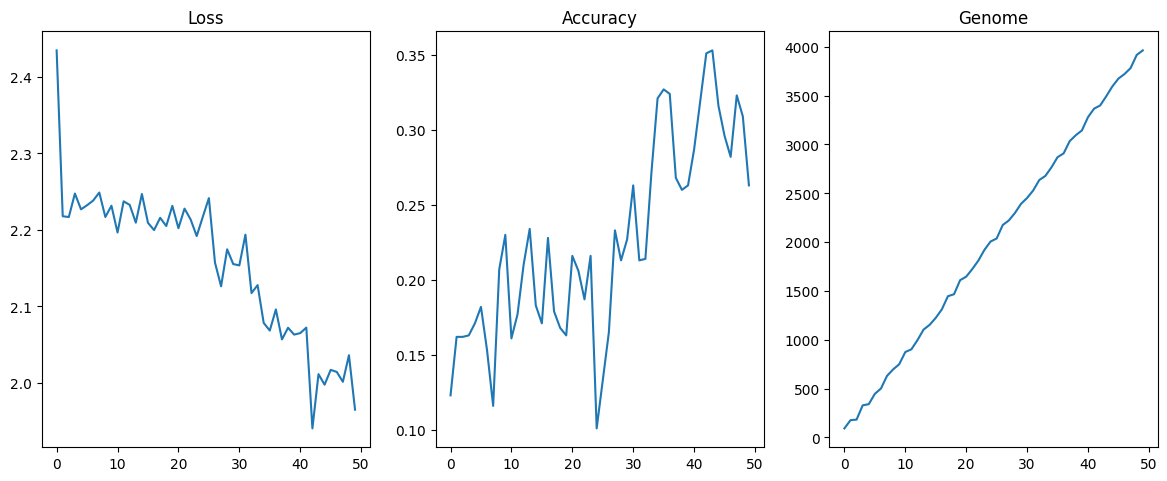

In [48]:
with torch.no_grad():
    neat_losses = TRAINER.run(50,)


Images: (torch.Size([100, 64, 1, 16, 16]))
Predictions: tensor([[[ 1.2859e-01,  4.6085e-01, -3.9856e-01,  5.4426e-01,  1.3316e-01,
          -3.2942e-02, -3.6143e-01, -2.2368e-01, -8.5306e-01, -5.1245e-01],
         [ 6.5422e-01,  1.4256e-01, -1.0100e-01,  1.3671e+00,  4.9691e-01,
           4.9945e-01, -5.8973e-01, -1.2819e-01, -1.5320e+00,  7.1381e-02],
         [-6.3655e-01,  4.6009e-01,  2.1116e-01, -2.8634e-01, -2.3249e-01,
           2.8781e-01, -1.4988e-01, -3.7213e-02,  6.5659e-01, -1.6027e-01]],

        [[ 2.6243e-01, -5.6805e-01, -6.7130e-01,  1.1432e+00, -1.9282e-01,
          -1.2670e-01, -5.5488e-01,  5.4514e-01, -1.3057e+00, -1.1576e+00],
         [ 1.5316e-01,  2.7826e-04, -6.4593e-02,  3.6462e-01,  1.0226e+00,
           7.9053e-01, -8.2422e-01, -1.7800e-01, -9.5016e-02, -4.9144e-03],
         [-9.6753e-02,  6.4161e-01,  6.7216e-01,  1.5507e-01,  5.5418e-01,
          -5.6722e-02, -8.7664e-01, -6.7863e-01,  4.2184e-01, -1.2295e+00]],

        [[-1.8918e-01, -2.6202e-0

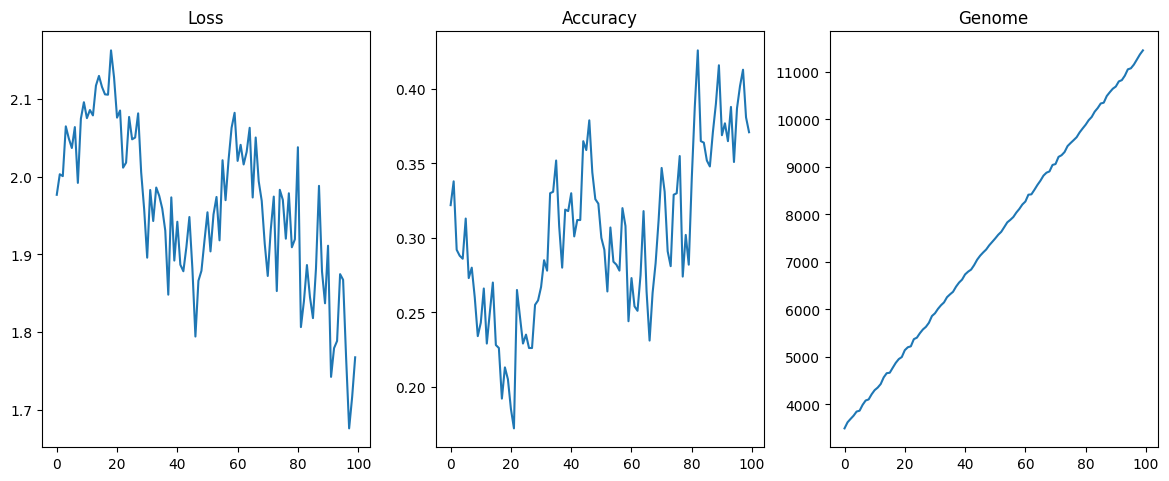

In [49]:
neat_losses =  TRAINER.run(100)

In [50]:
MODEL.eval();

In [51]:
POPULATION.save_dict(name='mnist', file_no=None, replace=False);

Successfully dumped NEAT Population save file to 'D:\PycharmProjects\Modified-NEAT\storage\neat_save\mnist-6.pkl'.


# Evaluate

In [52]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, mean=True))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, mean=True))*100

(81.04, 82.0918)

In [53]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, keys=POPULATION.best_genome.key))*100

(43.2, 50.06999999999999)

In [54]:
(1-get_accuracy(MODEL, train_inp, train_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100, \
(1-get_accuracy(MODEL, eval_inp, eval_out, BATCH_SIZE, guess=True, keys=POPULATION.best_genome.key))*100

(71.0, 72.81)

In [55]:
def get_indices(images: Tensor, labels: Tensor, include: Union[int, list[int]] = None,
                faulty: int = False, correct: int = False, shuffle=True,
                keys: Union[int, list[int]] = None):
    if isinstance(include, (int, float)):
        include = [include]
    if keys and not isinstance(keys, (tuple, list)):
        keys = [keys]
    error_indices = []
    mapping = POPULATION.get_mapping(consolidated=True)
    indices = list(range(len(images))) if not keys else [mapping[key] for key in keys]
    images, labels = images[indices], labels[indices]
    if faulty:
        if isinstance(faulty, bool):
            faulty = 16
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], faulty, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys) # shape(genomes, batch_size)
                # print(pred.shape)
                for index, errored in zip(batch, (pred!=labels[:, batch].to(MODEL.device)).mT):
                    # print(errored[:10])
                    if torch.any(errored):
                        error_indices.append(index)
        print(f"Found {len(error_indices)} record predictions with errors")
    valid_indices = []
    if correct:
        if isinstance(correct, bool):
            correct = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], correct, False):
                pred = MODEL.evaluate(images[:, batch].to(MODEL.device), keys=keys)
                for index, correct in zip(batch, (pred==labels[:, batch].to(MODEL.device)).mT):
                    if torch.any(correct):
                        valid_indices.append(index)
        print(f"Found {len(valid_indices)} valid record predictions ")
    indices_filtered = []
    for g_labels in labels.cpu():
        for x, record in enumerate(g_labels.cpu().tolist()):
            record_needed = include is None or record in include
            spec_type = x in error_indices or x in valid_indices
            no_type = not correct and not faulty
            if record_needed and (spec_type or no_type):
                indices_filtered.append(x)
    indices_filtered = list(set(indices_filtered))
    if shuffle:
        random.shuffle(indices_filtered)
    if len(indices_filtered) > 0:
        return indices_filtered
    else:
        raise ValueError(f"No indices available")

In [56]:
test_records = 24
MODEL.eval();

In [57]:
train_indices = get_indices(train_inp, train_out, faulty=BATCH_SIZE, keys=POPULATION.best_genome.key)
len(train_indices)

Found 432 record predictions with errors


432

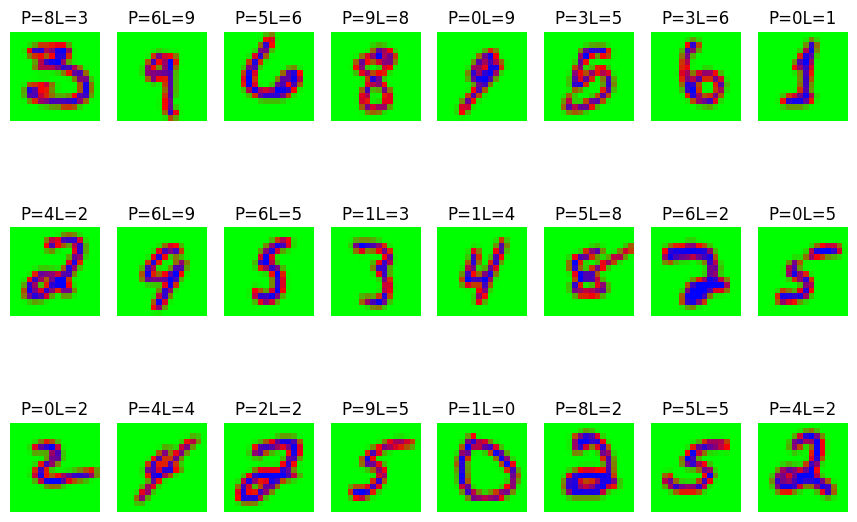

In [58]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [59]:
eval_indices = get_indices(eval_inp, eval_out, faulty=BATCH_SIZE, correct=False, keys=POPULATION.best_genome.key)
len(eval_indices)

Found 5007 record predictions with errors


5007

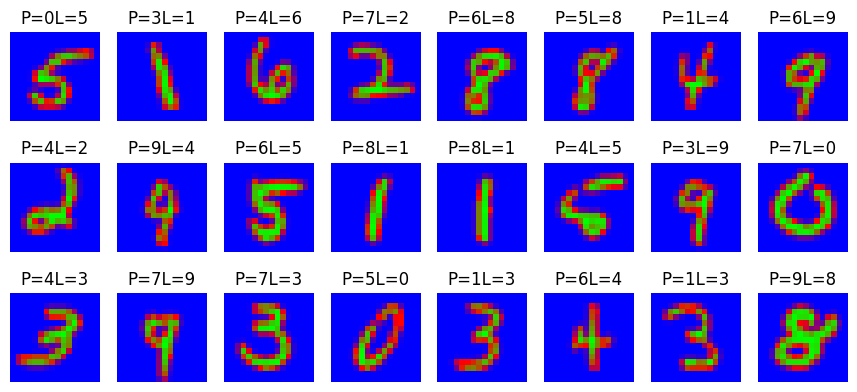

In [60]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

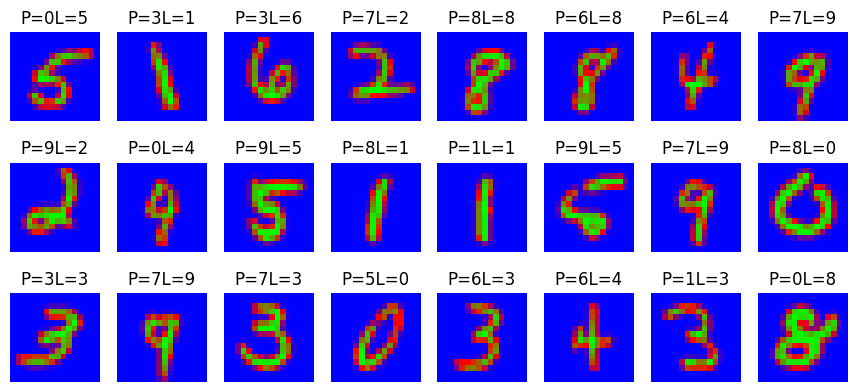

In [87]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

# PyTorch training

In [88]:
def train2(epochs: int, batch_size: int, key: int, show=True, checkpoints=5):
    torch.cuda.empty_cache()
    MODEL.requires_grad_(True)
    # attention.causal_mask = False
    optimizer = torch.optim.AdamW(MODEL.parameters(), 1e-3)

    losses = []
    acc_train, acc_eval = [], []
    ts, ud, ut = clock.perf_counter(), 0, epochs

    # ------------------------------ Training Data ------------------------------ #
    index = POPULATION.get_mapping()[key]
    inputs, outputs = train_inp[index].unsqueeze(0).to(MODEL.device), train_out[index].unsqueeze(0).to(MODEL.device)
    print(inputs.shape, outputs.shape)

    best_loss = torch.inf
    best_epoch = -1
    save_state = MODEL.state_dict()
    batches = get_batches(inputs.shape[1], batch_size, True)
    for epoch in range(epochs):
        try:
            loss: Tensor = 0
            for batch in batches:
                # if epoch == 0:
                #     print(inputs.shape, outputs.shape)
                inp = inputs[:, batch].to(MODEL.device)
                out = outputs[0, batch].to(MODEL.device)
                predictions = MODEL(inp, keys=key).squeeze(0)
                # if epoch == 0:
                #     print(inp.shape, predictions.shape, out.shape)
                batch_loss = F.cross_entropy(predictions, out)
                batch_loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                loss += batch_loss
            loss /= len(batches)

            losses.append(loss.cpu().item())
            acc_train.append(get_accuracy(MODEL, train_inp, train_out, batch_size, True, keys=key))
            acc_eval.append(get_accuracy(MODEL, eval_inp, eval_out, batch_size, True, keys=key))

            if epoch % checkpoints == 0 and loss < best_loss:
                best_loss = loss
                save_state = MODEL.state_dict()
                best_epoch = epoch

            ud += 1
            eta(ts, ud, ut, f"training | loss={loss.cpu().item():.4e} | "
                            f"best={best_loss.cpu().item():.4e} | "
                            f"epoch={best_epoch}")
        except KeyboardInterrupt:
            break
    print(f"\nFinished training in {clock.perf_counter() - ts:.2f}s")

    MODEL.load_state_dict(save_state)

    # attention.causal_mask = True
    if show:
        plt.close()
        axes = plt.subplots(1, 2, figsize=(10.8, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(np.log10(losses))
        axes[0].set_title('Loss')
        axes[1].plot(acc_train, label='train')
        axes[1].plot(acc_eval, label='eval')
        axes[1].legend()
        axes[1].set_title('Accuracy')

    MODEL.requires_grad_(False)
    torch.cuda.empty_cache()
    return losses

torch.Size([1, 1000, 1, 16, 16]) torch.Size([1, 1000])
training | loss=4.8734e-03 | best=4.8734e-03 | epoch=99: progress=100% eta=0sec
Finished training in 40.11s


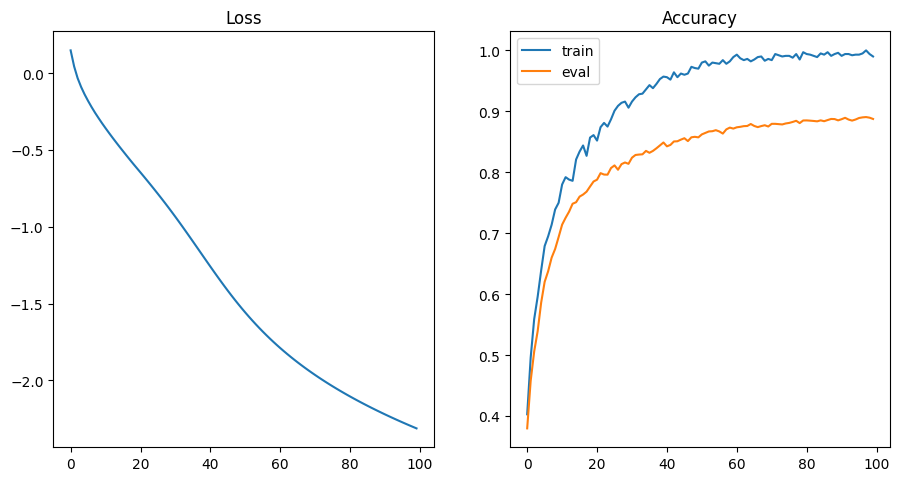

In [89]:
train_losses = train2(100, BATCH_SIZE*8, POPULATION.best_genome.key, checkpoints=1)

In [90]:
list(POPULATION.genomes.keys())[:15], POPULATION.best_genome

([11655,
  11233,
  11679,
  10869,
  11238,
  11025,
  11690,
  11120,
  11647,
  11665,
  11643,
  11455,
  10516,
  11000,
  11652],
 <numba.experimental.jitclass.boxing.Genome at 0x1a41ed665f0>)

In [91]:
extra_key = list(POPULATION.genomes.keys())[1]
extra_key

11233

torch.Size([1, 1000, 1, 16, 16]) torch.Size([1, 1000])
training | loss=1.1816e-03 | best=1.1816e-03 | epoch=199: progress=100% eta=0sec
Finished training in 90.47s


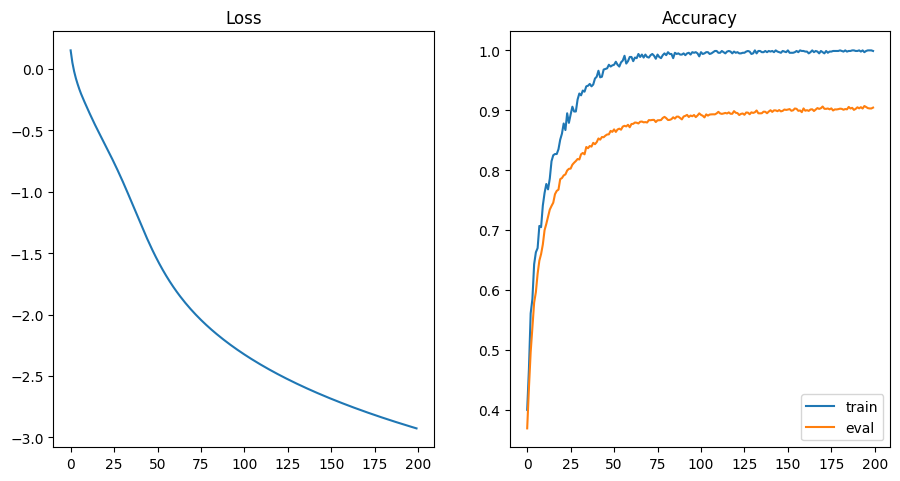

In [92]:
train2(200, BATCH_SIZE*8, extra_key, checkpoints=1);

In [93]:
extra_key2 = list(POPULATION.genomes.keys())[3]
extra_key2

10869

torch.Size([1, 1000, 1, 16, 16]) torch.Size([1, 1000])
training | loss=1.2059e-03 | best=1.2059e-03 | epoch=199: progress=100% eta=0sec
Finished training in 97.79s


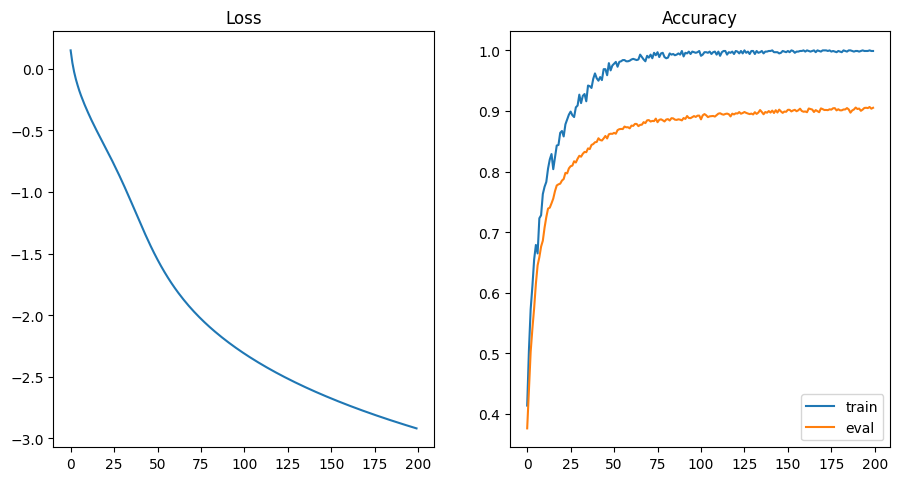

In [94]:
train2(200, BATCH_SIZE*8, extra_key2, checkpoints=1);

In [95]:
keys_to_check = [*[g.key for g in POPULATION.best_genomes.values()], extra_key, extra_key2]
keys_to_check

[11655, 11233, 10869]

In [96]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, keys=POPULATION.best_genome.key)) * 100

(0.0, 9.07)

In [97]:
(1 - get_accuracy(MODEL, train_inp, train_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100, \
(1 - get_accuracy(MODEL, eval_inp, eval_out, 128, guess=True, keys=POPULATION.best_genome.key)) * 100

(0.6000000000000005, 11.450000000000005)

In [98]:
train_indices = get_indices(train_inp, train_out, faulty=None, keys=POPULATION.best_genome.key)

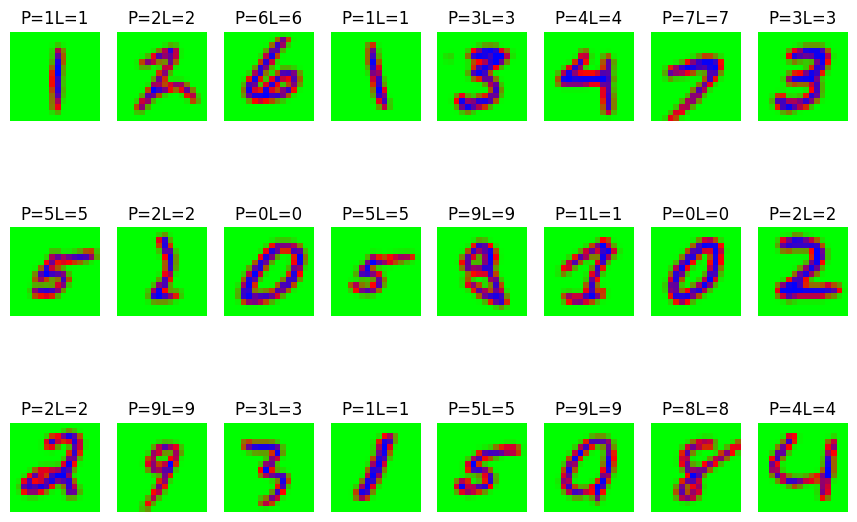

In [99]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [100]:
eval_indices = get_indices(eval_inp, eval_out, faulty=BATCH_SIZE*8, correct=False)
len(eval_indices)

Found 10000 record predictions with errors


10000

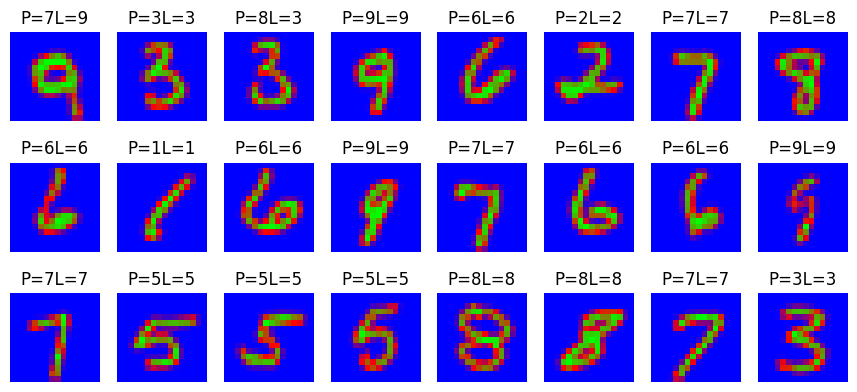

In [101]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))

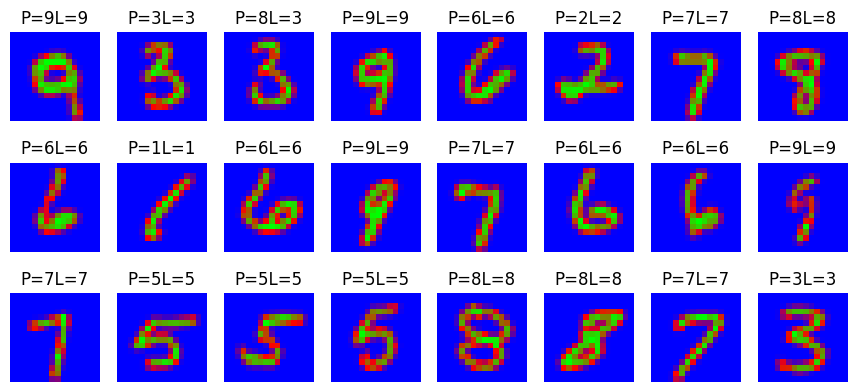

In [102]:
with torch.no_grad():
    # random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=POPULATION.best_genome.key)
show_batch(eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], cmap='brg', size=(480, 1080))